# **EXPT NO: 4 - 24BAD108**

# **PART A – Dataset Preparation**

In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Load CIFAR-10
(X, y), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Convert labels to 1D
y = y.flatten()
y_test = y_test.flatten()

# Use only 5,000 training images
X = X[:5000]
y = y[:5000]

# Use only 2,000 test images
X_test = X_test[:2000]
y_test = y_test[:2000]

# Split training data into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 4000
Validation images: 1000
Testing images: 2000


# **PART B – Implementing Transfer Learning**

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

# Resize CIFAR-10 images for ResNet50
IMG_SIZE = 96

def preprocess_images(images):
    images = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    return tf.keras.applications.resnet50.preprocess_input(images)

X_train_res = preprocess_images(X_train)
X_val_res = preprocess_images(X_val)
X_test_res = preprocess_images(X_test)

# Load pre-trained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze feature extraction layers
base_model.trainable = False

# Build model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## **PART C – Model Training and Evaluation**

In [6]:
# Train the transfer learning model

history = model.fit(
    X_train_res,
    y_train,
    validation_data=(X_val_res, y_val),
    epochs=5,
    batch_size=64
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(
    X_test_res,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 192s 3s/step - accuracy: 0.6605 - loss: 1.1097 - val_accuracy: 0.7790 - val_loss: 0.6224
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.8280 - loss: 0.4970 - val_accuracy: 0.8020 - val_loss: 0.5746
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 192s 3s/step - accuracy: 0.8752 - loss: 0.3698 - val_accuracy: 0.8070 - val_loss: 0.5669
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.8935 - loss: 0.3131 - val_accuracy: 0.8160 - val_loss: 0.5767
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.9245 - loss: 0.2091 - val_accuracy: 0.8200 - val_loss: 0.5712
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8205 - loss: 0.5516
Test Loss: 0.55162513256073
Test Accuracy: 0.8205000162124634


**Accuracy vs Epoch**

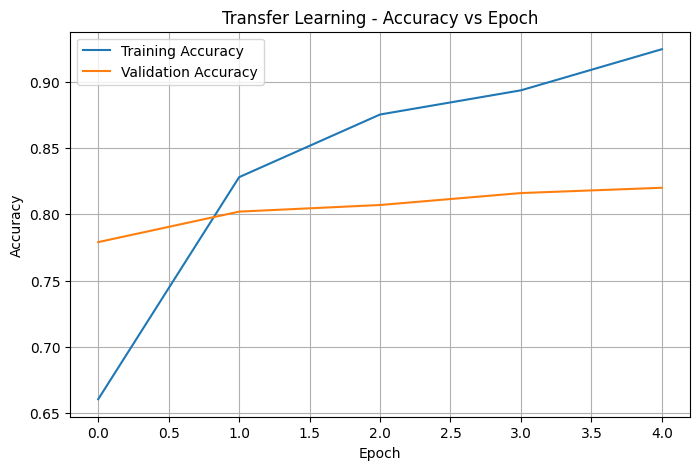

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Transfer Learning - Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Loss vs Epoch**

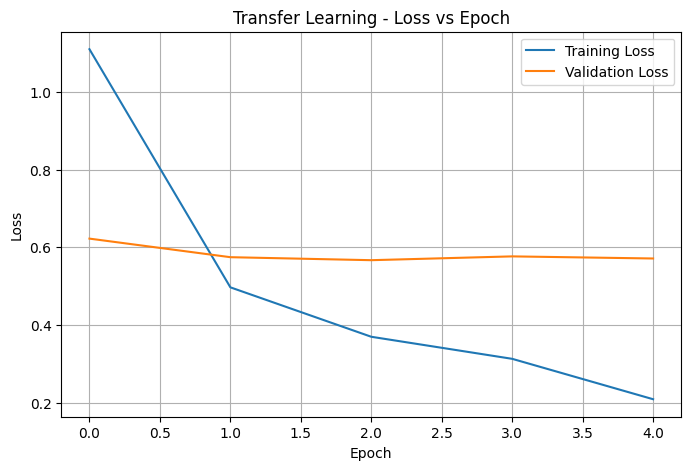

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Transfer Learning - Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# **PART D – Using Hugging Face Pre-trained Models**

In [9]:
!pip install -q transformers torch torchvision

In [10]:
from transformers import pipeline
from PIL import Image

# Load Hugging Face image classification model
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

# Select a sample CIFAR-10 image
sample_image = Image.fromarray(X_test[0])

# Convert image to suitable size
sample_image = sample_image.resize((224, 224))

# Make prediction
results = classifier(sample_image)

print("Hugging Face Predictions:")
for result in results[:5]:
    print(result)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face Predictions:
{'label': 'tabby, tabby cat', 'score': 0.25434672832489014}
{'label': 'Egyptian cat', 'score': 0.15551269054412842}
{'label': 'tiger cat', 'score': 0.05738494545221329}
{'label': 'polecat, fitch, foulmart, foumart, Mustela putorius', 'score': 0.030777405947446823}
{'label': 'fox squirrel, eastern fox squirrel, Sciurus niger', 'score': 0.028474928811192513}


In [11]:
# Prediction using ResNet50 transfer learning model

sample = preprocess_images(
    np.expand_dims(X_test[0], axis=0)
)

prediction = model.predict(sample)

predicted_class = np.argmax(prediction)

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Actual Class:", class_names[y_test[0]])
print("ResNet50 Predicted Class:",
      class_names[predicted_class])

print("\nHugging Face Prediction:")
print(results[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Actual Class: cat
ResNet50 Predicted Class: cat

Hugging Face Prediction:
{'label': 'tabby, tabby cat', 'score': 0.25434672832489014}


In [12]:
# Save the trained model

model.save("resnet50_transfer_learning.keras")

print("Model saved successfully.")

Model saved successfully.


In [18]:
!git config --global user.email "shailesh@example.com"
!git config --global user.name "Shailesh-0305"
!git init
!git add .
!git commit -m "Added Transfer Learning Experiment - Local Save"
print("Successfully saved changes to local Git repository.")

Reinitialized existing Git repository in /content/.git/
On branch main
nothing to commit, working tree clean
Successfully saved changes to local Git repository.
